<a href="https://colab.research.google.com/github/gourisha96/IPL-2008-2026-Analysis/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IPL DATA ANALYSIS (2008-2026)--
This project analyzes IPL match data from 2008 to 2026 using python,numpy, pandas and SQL to uncover trends and insights.

In [4]:
import pandas as pd
import numpy as np

DATASET LOADING--
In this section, we load the IPL dataset into pandas DataFrames.

In [6]:
deliveries=pd.read_csv("/content/deliveries.csv")
matches=pd.read_csv("/content/matches.csv")

DATA UNDERSTANDING--
We examine the structure, data types, and summary statistics of the dataset.

In [7]:
print(matches.shape)
print(matches.head())
print(matches.info())
print(matches.isnull().sum())
print(matches.describe())

(1218, 17)
   match_id  season  match_date       city  \
0   1082591    2017  2017-04-05  Hyderabad   
1   1082592    2017  2017-04-06       Pune   
2   1082593    2017  2017-04-07     Rajkot   
3   1082594    2017  2017-04-08     Indore   
4   1082595    2017  2017-04-08  Bengaluru   

                                       venue                        team1  \
0  Rajiv Gandhi International Stadium, Uppal          Sunrisers Hyderabad   
1    Maharashtra Cricket Association Stadium       Rising Pune Supergiant   
2     Saurashtra Cricket Association Stadium                Gujarat Lions   
3                     Holkar Cricket Stadium              Kings XI Punjab   
4                      M.Chinnaswamy Stadium  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1               Mumbai Indians       Rising Pune Supergiant         field   
2        Kolkata K

Data Cleaning--
Missing values and unnecassary columns were handled to prepare the data for analysis.

In [8]:
matches['match_date']=pd.to_datetime(matches['match_date'])
matches['match_date'].dtype
matches['city']=matches['city'].fillna('unknown')
matches['winner']=matches['winner'].fillna('no result')
matches['player_of_match']=matches['player_of_match'].fillna('Not awarded')
matches['win_by_runs']=matches['win_by_runs'].fillna(0)
matches['win_by_wickets']=matches['win_by_wickets'].fillna(0)
matches.drop('created_at',axis=1,inplace=True)

Exploratory Data Analysis

In [9]:
import matplotlib.pyplot as plt


# Number of matches played each season


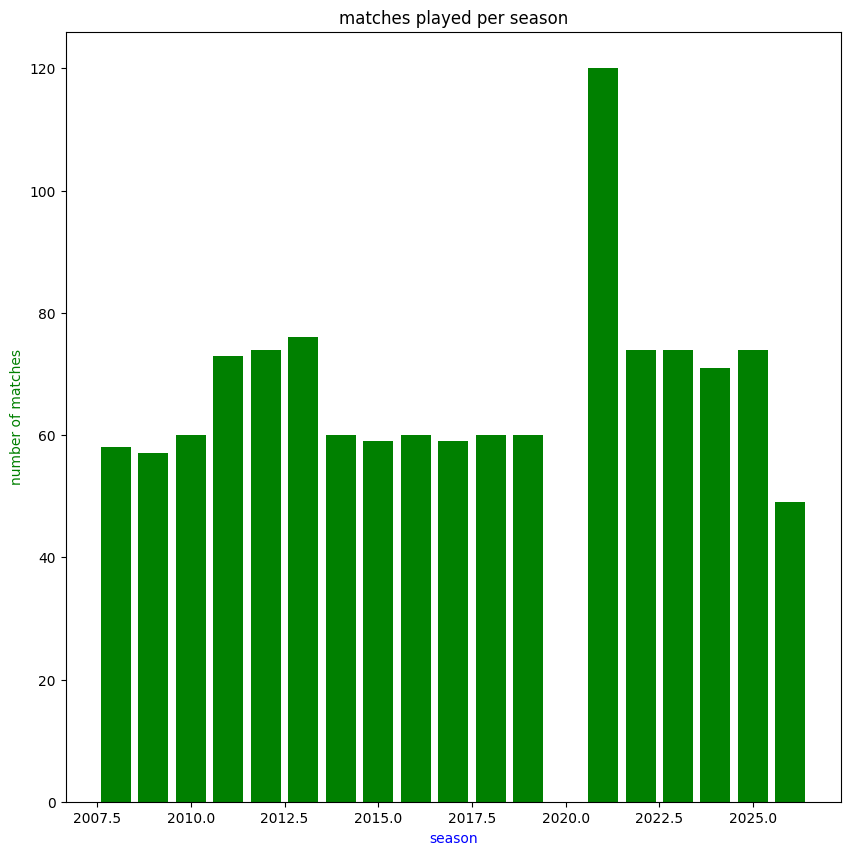

In [10]:
df=matches['season'].value_counts().sort_index()
plt.figure(figsize=[10,10])
plt.bar(df.index, df.values,color="g")
plt.xlabel("season",color="b")
plt.ylabel("number of matches",color="g")
plt.title("matches played per season")
plt.show()

# Top 10 teams by wins

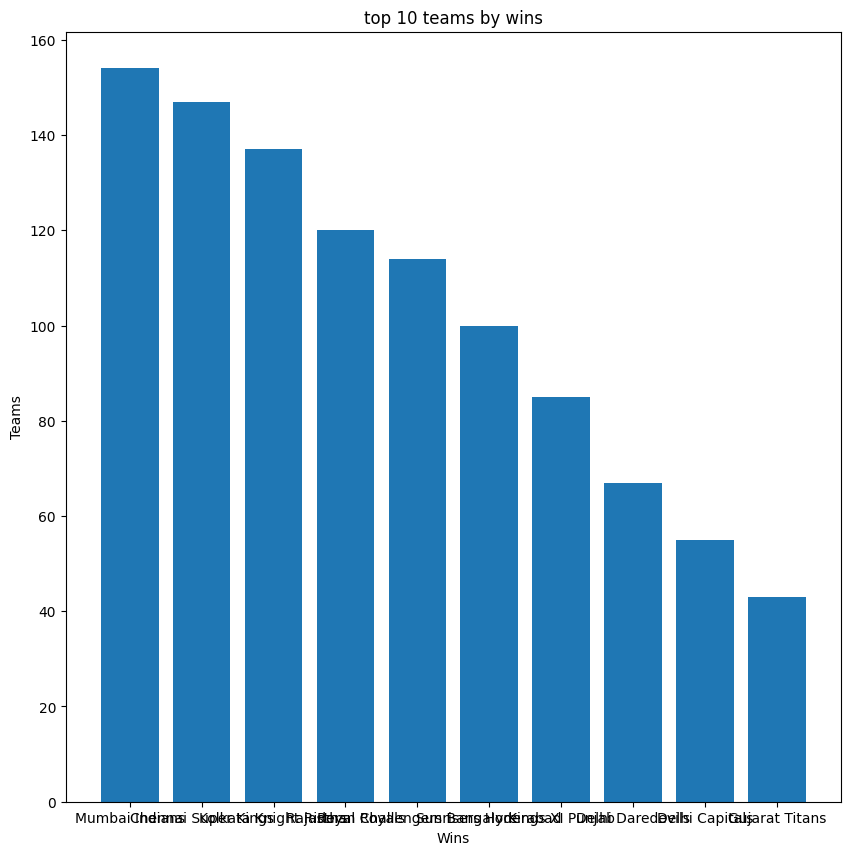

In [11]:
top_teams=matches['winner'].value_counts().head(10)
plt.figure(figsize=[10,10])
plt.bar(top_teams.index,top_teams.values)
plt.xlabel("Wins")
plt.ylabel("Teams")
plt.title("top 10 teams by wins")
plt.show()

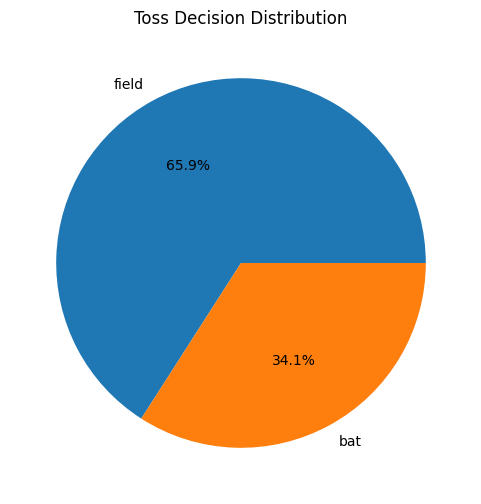

In [12]:
toss=matches['toss_decision'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(toss.values,labels=toss.index,autopct='%1.1f%%')
plt.title('Toss Decision Distribution')
plt.show()

Top 10 player of the match winners

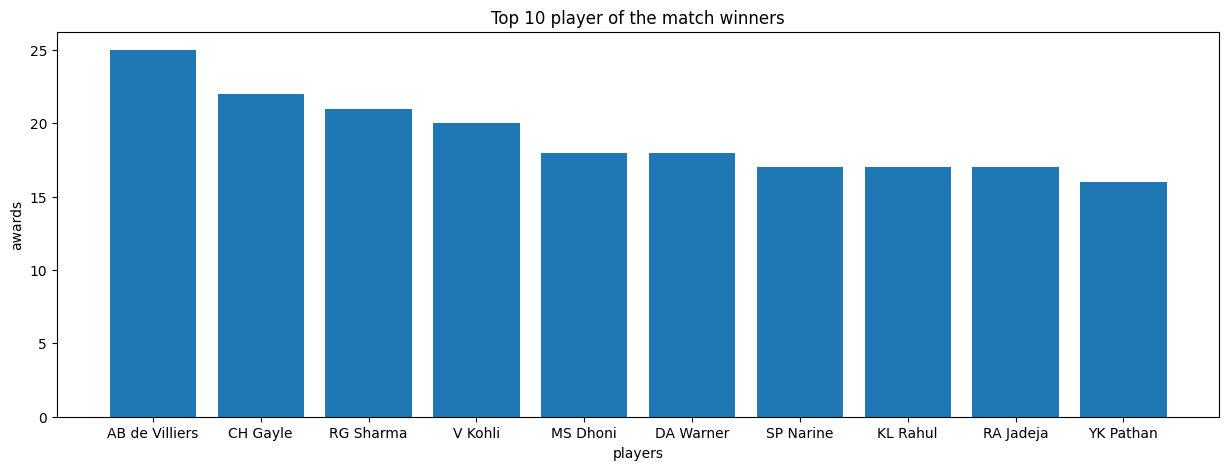

In [ ]:
pom=matches['player_of_match'].value_counts().head(10)
plt.figure(figsize=(15,5))
plt.bar(pom.index,pom.values)
plt.title('Top 10 player of the match winners')
plt.ylabel('awards')
plt.xlabel('players')
plt.show()

Top 10 Venues

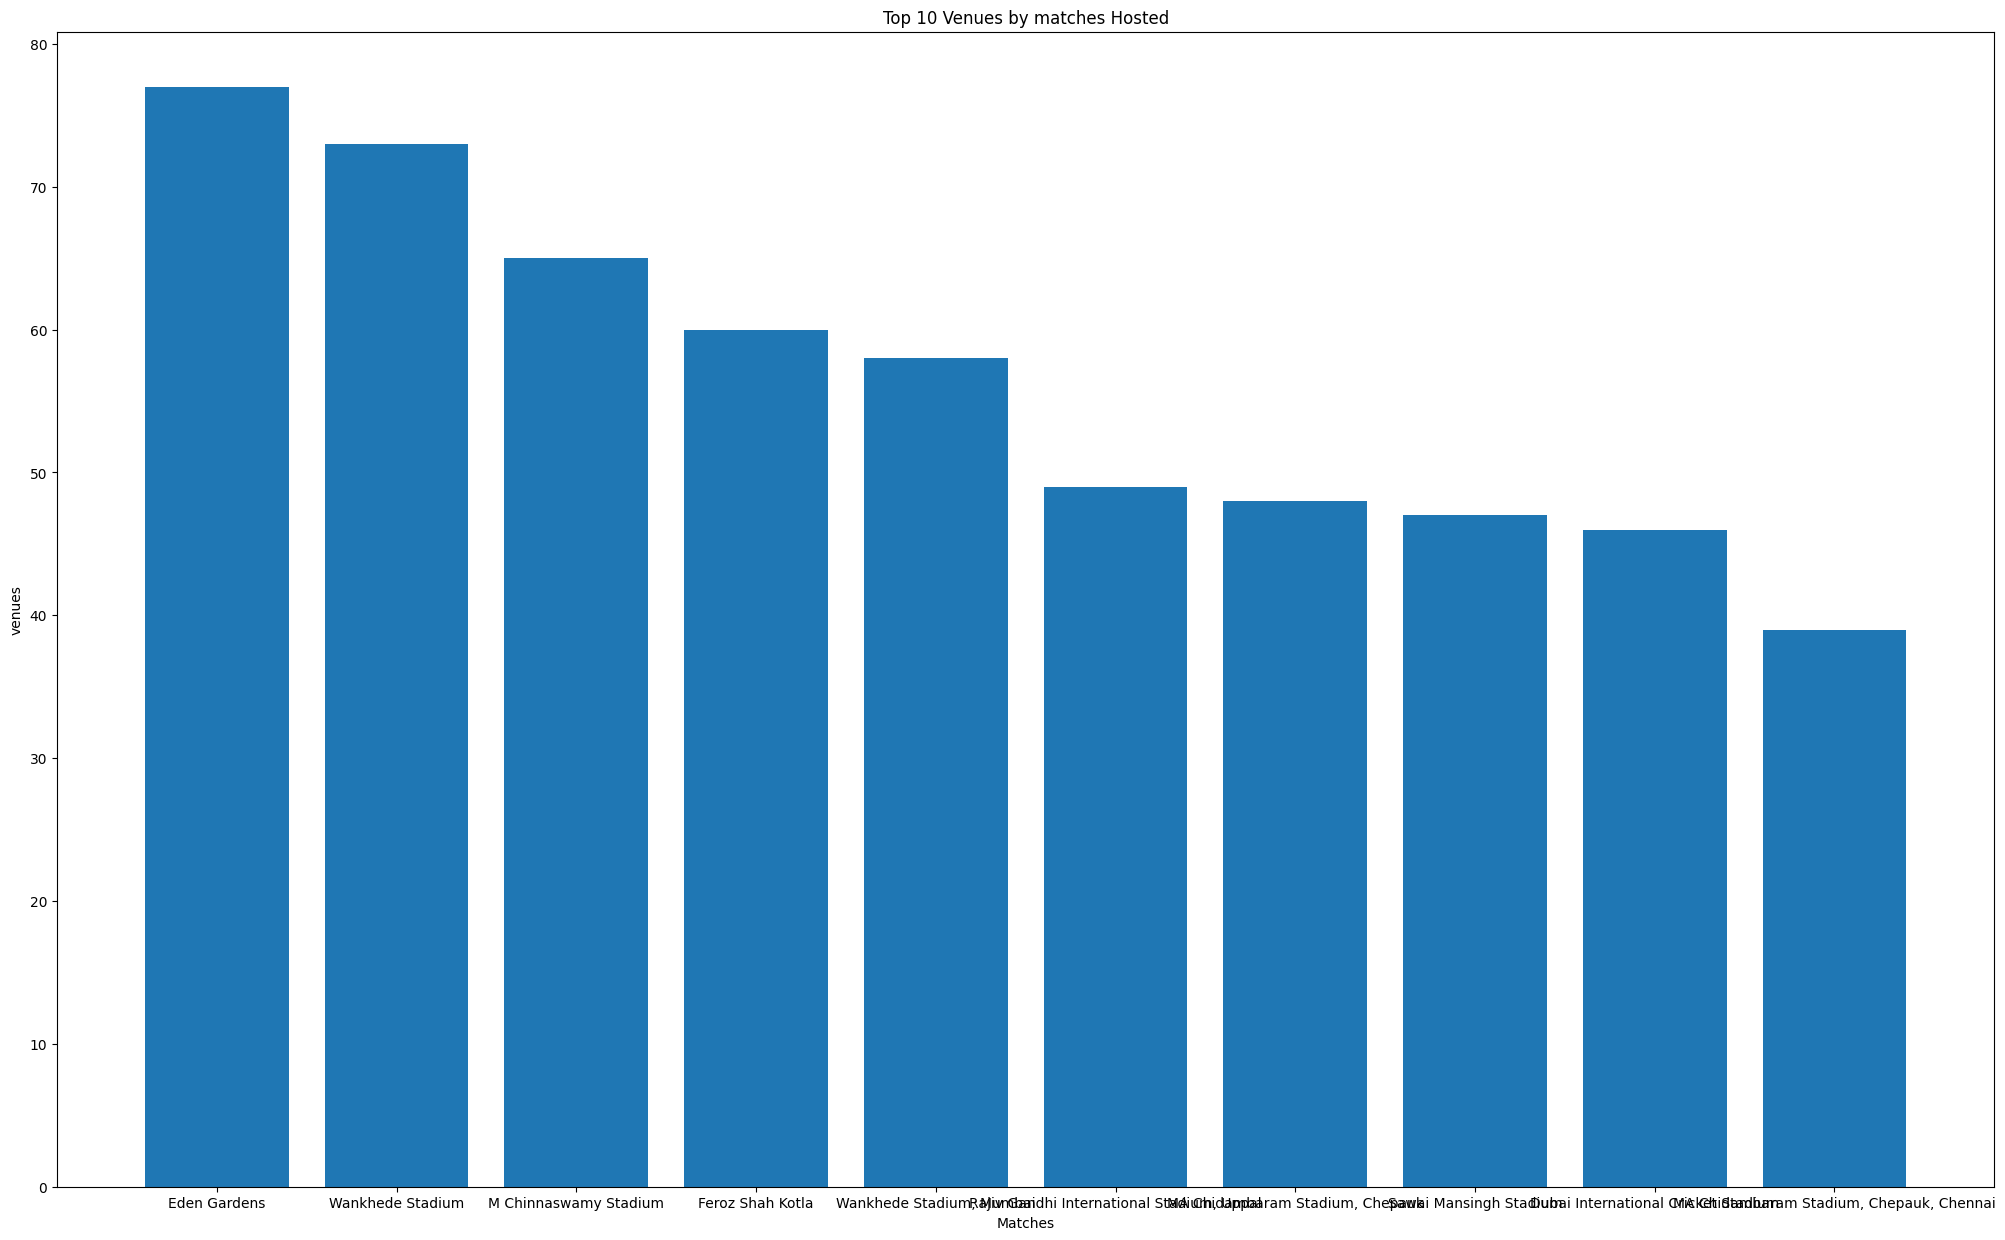

In [ ]:
venue=matches['venue'].value_counts().head(10)
plt.figure(figsize=[10,5])
plt.bar(venue.index,venue.values)
plt.title('Top 10 Venues by matches Hosted')
plt.xlabel('Matches')
plt.ylabel('venues')
plt.show()

win by Runs Distribution

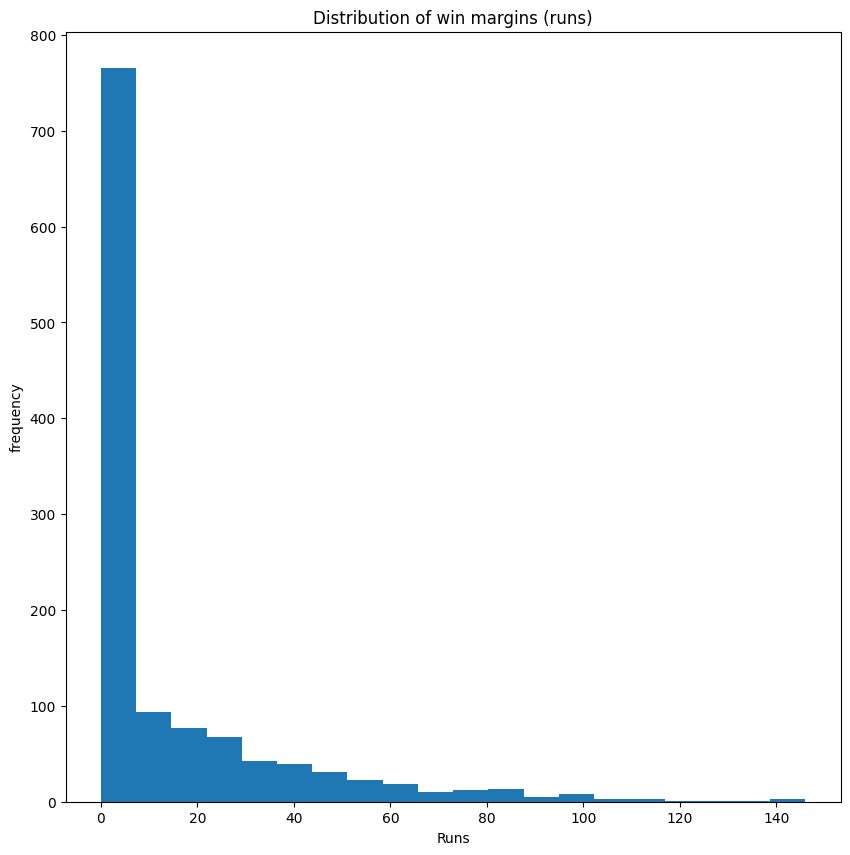

In [ ]:
plt.figure(figsize=[10,10])
plt.hist(matches['win_by_runs'],bins=20)
plt.title('Distribution of win margins (runs)')
plt.xlabel('Runs')
plt.ylabel('frequency')
plt.show()